In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
)
import xgboost as xgb

In [2]:
# ── 1. Load & Prepare Data ──────────────────────────────────────────────────

data = load_breast_cancer()
X, y_raw = data.data, data.target

# Remap: malignant (0) → anomaly (1), benign (1) → normal (0)
y = np.where(y_raw == 0, 1, 0)

print("=" * 60)
print("  XGBoost Anomaly Detection — Breast Cancer Dataset")
print("=" * 60)
print(f"\n  Features   : {X.shape[1]}")
print(f"  Samples    : {X.shape[0]}")
print(f"  Normal (0) : {(y == 0).sum()}  (benign)")
print(f"  Anomaly(1) : {(y == 1).sum()}  (malignant)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

  XGBoost Anomaly Detection — Breast Cancer Dataset

  Features   : 30
  Samples    : 569
  Normal (0) : 357  (benign)
  Anomaly(1) : 212  (malignant)


In [3]:
# ── 2. Compute Class Weights (handles imbalance) ────────────────────────────

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"\n  scale_pos_weight : {scale_pos_weight:.3f}")


  scale_pos_weight : 1.679


In [4]:
# ── 3. Train XGBoost ────────────────────────────────────────────────────────

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
print("\n  Model training complete ✓")


  Model training complete ✓


In [5]:
# ── 4. Evaluate ─────────────────────────────────────────────────────────────

y_pred      = model.predict(X_test)
y_prob      = model.predict_proba(X_test)[:, 1]   # anomaly probability

roc_auc     = roc_auc_score(y_test, y_prob)
avg_prec    = average_precision_score(y_test, y_prob)

print(f"\n  ROC-AUC Score        : {roc_auc:.4f}")
print(f"  Avg Precision Score  : {avg_prec:.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))


  ROC-AUC Score        : 0.9960
  Avg Precision Score  : 0.9950

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        90
     Anomaly       1.00      0.96      0.98        53

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.98       143
weighted avg       0.99      0.99      0.99       143



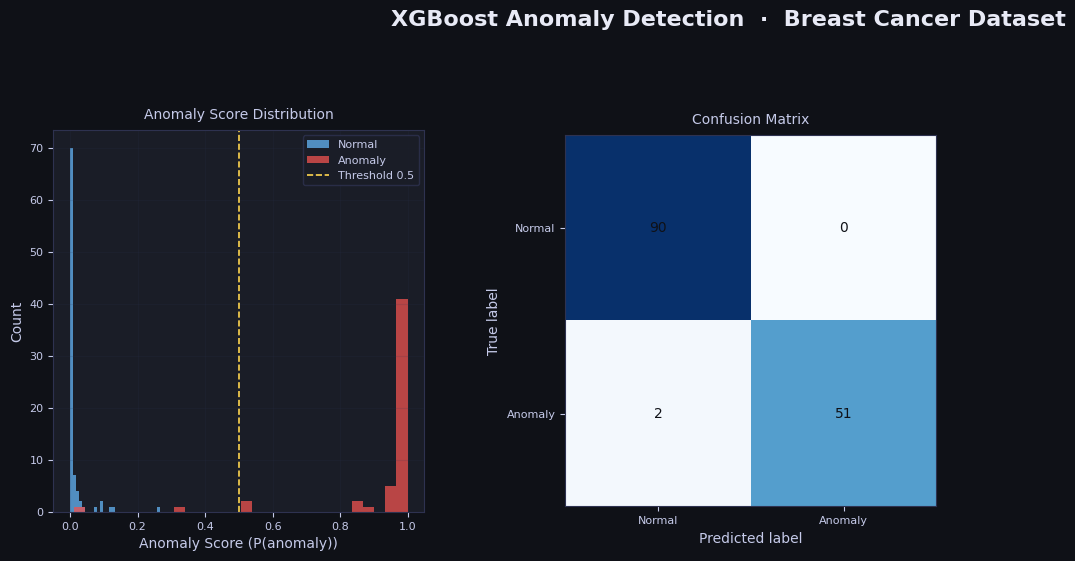

In [6]:
# ── 5. Visualise ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor="#0f1117")
fig.suptitle(
    "XGBoost Anomaly Detection  ·  Breast Cancer Dataset",
    fontsize=16, color="#e8eaf6", fontweight="bold", y=0.98,
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

NORM_COL    = "#64b5f6"   # blue  — normal
ANOM_COL    = "#ef5350"   # red   — anomaly
GRID_ALPHA  = 0.15
BG          = "#1a1d27"
TEXT        = "#c5cae9"

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=10, pad=8)
    ax.tick_params(colors=TEXT, labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor("#2e3250")
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.grid(color="#2e3250", alpha=GRID_ALPHA)

# — 5a. Anomaly Score Distribution ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(y_prob[y_test == 0], bins=30, color=NORM_COL, alpha=0.75,
         label="Normal", edgecolor="none")
ax1.hist(y_prob[y_test == 1], bins=30, color=ANOM_COL, alpha=0.75,
         label="Anomaly", edgecolor="none")
ax1.axvline(0.5, color="#ffd54f", ls="--", lw=1.2, label="Threshold 0.5")
ax1.legend(fontsize=8, labelcolor=TEXT, facecolor=BG, edgecolor="#2e3250")
ax1.set_xlabel("Anomaly Score (P(anomaly))")
ax1.set_ylabel("Count")
style_ax(ax1, "Anomaly Score Distribution")

# — 5b. Confusion Matrix ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomaly"])
disp.plot(ax=ax4, colorbar=False, cmap="Blues")
ax4.set_title("Confusion Matrix", color=TEXT, fontsize=10, pad=8)
ax4.tick_params(colors=TEXT, labelsize=8)
ax4.xaxis.label.set_color(TEXT)
ax4.yaxis.label.set_color(TEXT)
for text in ax4.texts:
    text.set_color("#0f1117")
ax4.set_facecolor(BG)
for sp in ax4.spines.values():
    sp.set_edgecolor("#2e3250")